# Project: Harry Potter characters

The ideas of our analysis is to discover/ do some interessting findings about the Harry Potter Universe and the relationships between the characters. We want to better understand the Wizarding World and see if some intuations are confirmes by a graph analysis. 
The main questions we want to awnser are:
* Do the number of citation in the books of each character really reflects its centrality in the universe.
* Most of the characters of Harry Potter universe can by said as "good" or "bad". If we spleet all the characters that way, who is the most "neutral" character (most balanced good/bad links ratio)? And can this measure be associated with any kind of centrality?
* Are the Hogward houses a good way to split the characters?: do they form good communities? Does the vocabulary associated with the characters of each houses relfects the "values" of each houses? Which houses have the most positive vocabulary?
* Are Blood-Status a better way to split the Harry Potter characters? Do they form good communities?

This notebook will be spet in 5 parts:

1. Download of the data and construction of the network
2. Basic Statistics about the Network
3. Number of citations
4. Dark/Bright side centrality
5. Hogward Houses text (sentiment and TF_IDF)
6. Communities (Hogward houses, Blood-Status or neither)

The general structure of our analysis is:

## 1. Download of the data and construction of the network

* First we have looked for the most complete and large list of Harry Potter character we could find online (https://beyondhogwarts.com/harry-potter/books/character-list/)
* Then, manually we have constructed the txt file containing the list of all characters. We took all the chracters of this online list and checked what was the title of its corresponding fandom wiki page (https://harrypotter.fandom.com/wiki/{name}).
* In another notebook, we go through every names in this list and for each character we open the associated fandom wiki page's wikitext and create a local file to store the wikitext in a .txt file.
* To have all the wikitext accessible simply (without creating all the local files everytime), we pushed all the wikitext files as well as the hole list of characters name on our public github (https://github.com/EricBrevilliers/Harry_Potter_Graph)
* In the next cell, we go through the list of names on github to retrieve a list of character names.

In [1]:
# Go through the list of names on github to retrieve a list of character names
import urllib.request
import requests

# Read the file with the wikitext of the harry_Potter_characters list and extract the names
url_list = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/list_characters/harry_Potter_characters.txt"

response_list = requests.get(url_list)
names = [] # Initialize the list

if response_list.status_code == 200:
    content_list = response_list.text
    # We divide the string "content_list" in a list (one string/name per line)
    names = content_list.splitlines()
    
    # Ensure that there is no empty name
    names = [name for name in names if name.strip()]
    names = sorted(list(set(names)))
    print(f"Found {len(names)} names.")
else:
    print(f"Error retrieving file: {response_list.status_code}")

Found 412 names.


* In the next cell, we go through every characters previously added in the list and make each of them being a node. For all the characters we also search in the github the associated wikitext and use it to add a ***word_count* attribute** to each node and to add the edges.

In [2]:
# Go through every wikitext we have already saved in our github and construct the graph

import requests
import networkx as nx
import re

HpGraph = nx.DiGraph()
name_set = set(names)
names_clean = [name.replace('_', ' ').replace('%27', "'") for name in names] # clean more lisible names
names_url   = [name.replace('%27', '%2527') for name in names] # repcise name for the url

raw_to_clean = dict(zip(names, names_clean)) # Ex: raw_to_clean["Harry_Potter"] -> "Harry Potter"
raw_to_url   = dict(zip(names, names_url)) # Ex: raw_to_clean["Hermione_Granger%27s_mother"] -> "Hermione_Granger%2527s_mother"

print(f"Building graph from {len(names)} characters...")

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
    
        # Adds the node and the word_count attribute
        words = re.findall(r'\b\w+\b', content)
        word_count = len(words)
        HpGraph.add_node(name_clean, word_count=word_count)

        # Finds everything between [[ and the first |, #, or ]
        links = re.findall(r'\[\[([^\]\|#]+)', content)

        # Loop over all found links
        for link in links:
            # Filter to ignore 'File:', 'Category:', 'Image:', etc.
            if ':' in link:
                continue
            
            link_clean = link.strip().replace(' ', '_').replace("'", "%27")
            
            # We check if the normalized link is in our 'name_set'
            if link_clean in name_set:
                # Avoid a node pointing to itself
                if name != link_clean:
                    HpGraph.add_edge(name_clean, link)
    else:
        # It's normal to have some errors if a file was not
        # correctly saved or if the name has a typo
        print(f"[Warning] Failed to load: {name} (Status: {response.status_code})")

print(f"Graph construction complete. {HpGraph.number_of_nodes()} nodes added, {HpGraph.number_of_edges()} edges created.")

Building graph from 412 characters...
Graph construction complete. 412 nodes added, 6928 edges created.


* In the next cell we filter the newtowrk node to remove the isolated nodes

In [3]:
# Identify isolated nodes and remove them
nodes_to_remove = []
for node in HpGraph.nodes():
    if HpGraph.in_degree(node) == 0 and HpGraph.out_degree(node) == 0:
        nodes_to_remove.append(node)
        
HpGraph_noIsolatedNodes = HpGraph.copy()
HpGraph_noIsolatedNodes.remove_nodes_from(nodes_to_remove)
print(f"{len(nodes_to_remove)} isolated nodes deleted. {HpGraph_noIsolatedNodes.number_of_nodes()} nodes still in network.")

21 isolated nodes deleted. 391 nodes still in network.


* In the next cell we filter the network to only keep the larger connected component and we build the "twin" undirected graph.

In [4]:
# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.weakly_connected_components(HpGraph))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_connected = HpGraph.subgraph(largest_component).copy()
else:
    HpGraph_connected = HpGraph.copy()

print(f"Largest connected component contains {HpGraph_connected.number_of_nodes()} nodes")

HpGraph_undir = HpGraph_connected.to_undirected()

Largest connected component contains 387 nodes


## 2. Basic Statistics about the Network

### 2.1 First network information

#### 2.1.1 Basic Network information

In this section, we compute the most fundamental characteristics of the graph, including:
- The total number of nodes (characters)  
- The total number of edges (links between characters)  
- The density of the directed network

These metrics provide a first overview of how connected the Harry Potter character graph is.

In [5]:
# Basic Network Statistics: nodes, edges, density

# Get the number of nodes and edges
num_nodes = HpGraph_connected.number_of_nodes()
num_edges = HpGraph_connected.number_of_edges()

print("--- Basic Network Stats ---")
print(f"Nodes (Characters): {num_nodes}")
print(f"Edges (Links): {num_edges}")

# Density of a directed graph: edges / (N*(N-1))
# Calculate density, rounding to 4 decimals
if num_nodes > 1:
    max_possible_edges = num_nodes * (num_nodes - 1)
    density = num_edges / max_possible_edges
    print(f"Density: {density:.4f}")
else:
    print("Density: N/A")


--- Basic Network Stats ---
Nodes (Characters): 387
Edges (Links): 6924
Density: 0.0464


#### 2.1.2 Degree Statistic

To gain a deeper understanding of the structure of the Harry Potter character graph, we now compute:

- The **average in-degree** (how many characters link *to* a character)  
- The **average out-degree** (how many characters a character links *to*)  
- The **maximum in-degree**, and which character(s) receive the most links  
- The **maximum out-degree**, and which character(s) create the most links  

These metrics highlight the most central and influential characters in the network based on direct hyperlink connections.

In [6]:
# Compute in-degree and out-degree statistics

# Get dictionaries of degrees {node: degree}
in_degrees_dict = dict(HpGraph_connected.in_degree())
out_degrees_dict = dict(HpGraph_connected.out_degree())

# Calculate averages
avg_in = sum(in_degrees_dict.values()) / num_nodes
avg_out = sum(out_degrees_dict.values()) / num_nodes  # Note: avg_in and avg_out must be equal

# Find max values
max_in = max(in_degrees_dict.values())
max_out = max(out_degrees_dict.values())

# Find the characters with those max values
max_in_nodes = [node for node, deg in in_degrees_dict.items() if deg == max_in]
max_out_nodes = [node for node, deg in out_degrees_dict.items() if deg == max_out]

print(f"--- Degree Statistics ---")
print(f"Average in-degree: {avg_in:.4f}")
print(f"Average out-degree: {avg_out:.4f}")

print(f"\nMaximum in-degree: {max_in}")
print(f"Character(s) with maximum in-degree:")
for node in max_in_nodes:
    print(f"  - {node}")

print(f"\nMaximum out-degree: {max_out}")
print(f"Character(s) with maximum out-degree:")
for node in max_out_nodes:
    print(f"  - {node}")

--- Degree Statistics ---
Average in-degree: 17.8915
Average out-degree: 17.8915

Maximum in-degree: 280
Character(s) with maximum in-degree:
  - Harry Potter

Maximum out-degree: 168
Character(s) with maximum out-degree:
  - Harry Potter


The average in-degree and out-degree are both 17.8915, meaning a typical character page links to (or is linked by) about 18 other characters. This equality is expected in a directed graph.

Unsurprisingly, the character with the highest in-degree (280 links received) and the highest out-degree (168 links made) is **Harry Potter**, confirming his central role. His page is the most referenced, and it also links out to the widest range of other characters, making him the most structurally central node in the network.

#### 2.1.3 Degree Distributions

In the next cell we plot the distributions of in-degrees and out-degrees to understand how common highly connected characters are.  
These plots help reveal whether the network has a heavy-tailed structure (a few very connected characters and many with few links), which is typical for real-world hyperlink networks.

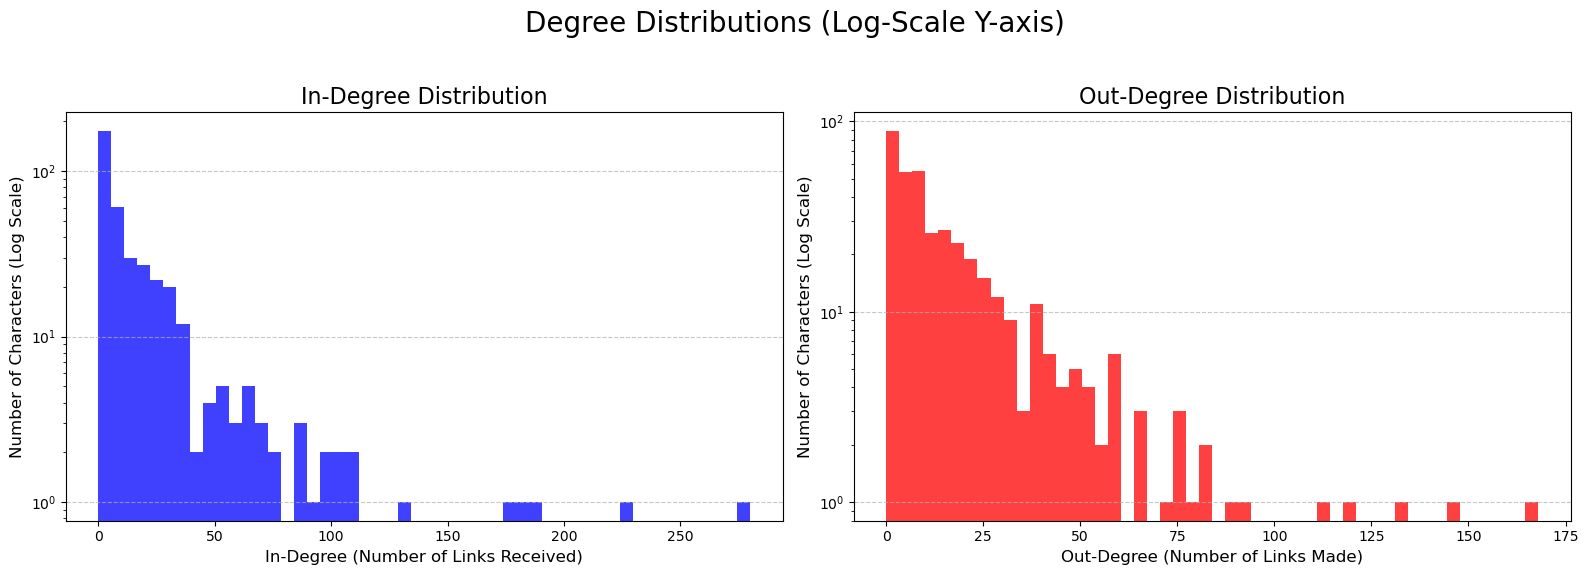

In [7]:
import matplotlib.pyplot as plt

# We already have the degree dictionaries from the previous cells
# in_degrees_dict = dict(HpGraph_connected.in_degree())
# out_degrees_dict = dict(HpGraph_connected.out_degree())

# Get just the degree values for plotting
in_degree_values = list(in_degrees_dict.values())
out_degree_values = list(out_degrees_dict.values())

# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: In-Degree Distribution ---
ax1.hist(in_degree_values, bins=50, alpha=0.75, color='b')
ax1.set_title('In-Degree Distribution', fontsize=16)
ax1.set_xlabel('In-Degree (Number of Links Received)', fontsize=12)
ax1.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax1.set_yscale('log') # Use log scale as requested
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Out-Degree Distribution ---
ax2.hist(out_degree_values, bins=50, alpha=0.75, color='r') 
ax2.set_title('Out-Degree Distribution', fontsize=16)
ax2.set_xlabel('Out-Degree (Number of Links Made)', fontsize=12)
ax2.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax2.set_yscale('log') # Use log scale
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Degree Distributions (Log-Scale Y-axis)', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

These histograms show the in-degree (left, blue) and out-degree (right, orange) for our 387-node network. The y-axis is on a log scale to better visualize the long tail.

Both plots show a clear **heavy-tailed distribution**, which is typical for real-world networks. This confirms our earlier finding:
* A vast majority of characters have a very low degree (they are "peripheral" characters).
* A "long tail" of a few, highly-connected nodes (like Harry Potter, Dumbledore, etc.) have a very high degree

### 2.2 Total size of the data 

We use the `word_count` attribute stored on each node and the raw wikitext files to estimate how large our corpus is.

In [8]:
# Total number of words in all character pages in the largest connected component

# Extract the "word_count" attribute for nodes in HpGraph_connected
word_counts = nx.get_node_attributes(HpGraph_connected, "word_count")

total_words = sum(word_counts.values())

print(f"Total number of words in all character pages: {total_words:,d}")

Total number of words in all character pages: 1,592,520


We approximate the total size of all wikitext files by summing the number of bytes downloaded for each character in the largest connected component. We then convert this total to megabytes.

In [9]:
import requests

total_bytes = 0

print(f"Calculating total file size for {HpGraph_connected.number_of_nodes()} nodes...")

for name in HpGraph_connected.nodes():
    
    base_filename = name.replace(" ", "_").replace("'", "%27")
    
    url_filename = base_filename.replace('%27', '%2527')
    
    # This URL now correctly points to the file on GitHub
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{url_filename}.txt"
    
    try:
        response = requests.get(url)
        if response.status_code == 200:
            total_bytes += len(response.content)
    except requests.exceptions.RequestException as e:
        print(f"Warning: Could not fetch {name}")

# Convert bytes to megabytes (using the 1024*1024 )
total_mb = total_bytes / (1024 * 1024)

print(f"\n--- Total File Size (for {HpGraph_connected.number_of_nodes()} nodes) ---")
print(f"Total Bytes: {total_bytes:,d}")
# Format to 4 decimal
print(f"Total Megabytes (MB): {total_mb:.4f} MB")

Calculating total file size for 387 nodes...

--- Total File Size (for 387 nodes) ---
Total Bytes: 9,946,601
Total Megabytes (MB): 9.4858 MB


Our final dataset (the largest connected component of the network) contains:

- **Total text:** 1,592,520 words  
- **Total file size:** approximately 9.486 MB  
- **Number of characters (nodes):** 387  

This text corpus will be used in the remainder of our analysis, both for network–text comparisons and for extracting semantic information from character pages.

## 3. Number of citations

### 3.1 Citations vs network centrality

So far, we have only looked at how characters are positioned inside the hyperlink network  
(degrees and connections). However, in the *Harry Potter* books, the “importance” of a character  
is often measured by **how many times they are mentioned**.

In this section, we compare **textual importance** (book citations) with **structural importance**  
in the network (degree, betweenness and eigenvector centrality).  
This allows us to evaluate whether “important in the story” also means  
“central in the Wizarding World network”.


In [10]:
import requests
import re

# URL of the file with character names and citation counts
url_citations = "https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/list_characters/characters_with_citation_counts.txt"
response_citations = requests.get(url_citations)

citation_raw = {}

if response_citations.status_code == 200:
    lines = response_citations.text.splitlines()

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Extract the last integer as the citation count
        match = re.search(r'(\d+)$', line)
        if not match:
            continue

        count = int(match.group(1))
        raw_name = line[:match.start()].strip()

        citation_raw[raw_name] = count
else:
    print(f"Error retrieving citation file: {response_citations.status_code}")

# Map raw names to clean names using the mapping built earlier
citation_clean = {}
for raw_name, count in citation_raw.items():
    if raw_name in raw_to_clean:
        clean_name = raw_to_clean[raw_name]
        citation_clean[clean_name] = count

# Keep only characters that are in the largest connected component
book_citations = {
    node: citation_clean.get(node, 0)
    for node in HpGraph_connected.nodes()
}

# Attach as a node attribute
nx.set_node_attributes(HpGraph_connected, book_citations, name="book_citations")

num_with_citations = sum(1 for v in book_citations.values() if v > 0)

print(f"Number of nodes in the largest component: {HpGraph_connected.number_of_nodes()}")
print(f"Nodes with non-zero citation information: {num_with_citations}")


Number of nodes in the largest component: 387
Nodes with non-zero citation information: 372


To compare book citations with network centrality, we now build a table containing:

- number of book citations  
- degree in the undirected network  
- betweenness centrality  
- eigenvector centrality  

This will allow us to compare narrative importance with structural importance.


In [36]:
import pandas as pd

# Degree in the undirected graph
degree_dict = dict(HpGraph_undir.degree(HpGraph_connected.nodes()))

# Betweenness centrality
betweenness_dict = nx.betweenness_centrality(HpGraph_undir, normalized=True)

# Eigenvector centrality
eigenvector_dict = nx.eigenvector_centrality(HpGraph_undir, max_iter=1000)

# Build a DataFrame combining all metrics
rows = []
for node in HpGraph_connected.nodes():
    rows.append({
        "character": node,
        "citations": book_citations.get(node, 0),
        "degree": degree_dict.get(node, 0),
        "betweenness": betweenness_dict.get(node, 0.0),
        "eigenvector": eigenvector_dict.get(node, 0.0),
    })

centrality_df = pd.DataFrame(rows)

# Keep only characters with at least one citation in the books
centrality_df_nonzero = centrality_df[centrality_df["citations"] > 0].copy()

print(f"Characters with centrality + citation info: {len(centrality_df_nonzero)}")

Characters with centrality + citation info: 372


We first inspect the most cited characters and see how central they are in the network.


In [37]:
top_cited = (
    centrality_df_nonzero
    .sort_values(by="citations", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_cited

,character,citations,degree,betweenness,eigenvector
0,Harry Potter,18956,285,0.290605,0.213481
1,Ronald Weasley,6464,195,0.067306,0.191444
2,Hermione Granger,5486,192,0.059702,0.188405
3,Albus Dumbledore,2421,201,0.089112,0.182850
4,Rubeus Hagrid,2024,115,0.015844,0.133919
5,Severus Snape,1956,150,0.030085,0.163445
6,Tom Riddle,1797,228,0.128302,0.195191
7,Sirius Black,1471,117,0.020903,0.138360
8,Draco Malfoy,1198,116,0.012276,0.142379
9,Fred Weasley,920,102,0.013339,0.131770


### 3.2 Comparaison citation / degree

If book citations truly reflect how “central” a character is, we expect a **positive correlation** between:
- number of citations  
- degree in the network  

We visualize this relationship.

--- Model Comparison Results (Degree) ---
Model Linear: R² = 0.4501
Model Polynomial (deg 2): R² = 0.7957
Model Exponential: R² = 0.9037

>> The best approximation is: Exponential with R² = 0.9037
>> Parameters recovered: a = 70.0824, b = 0.0195


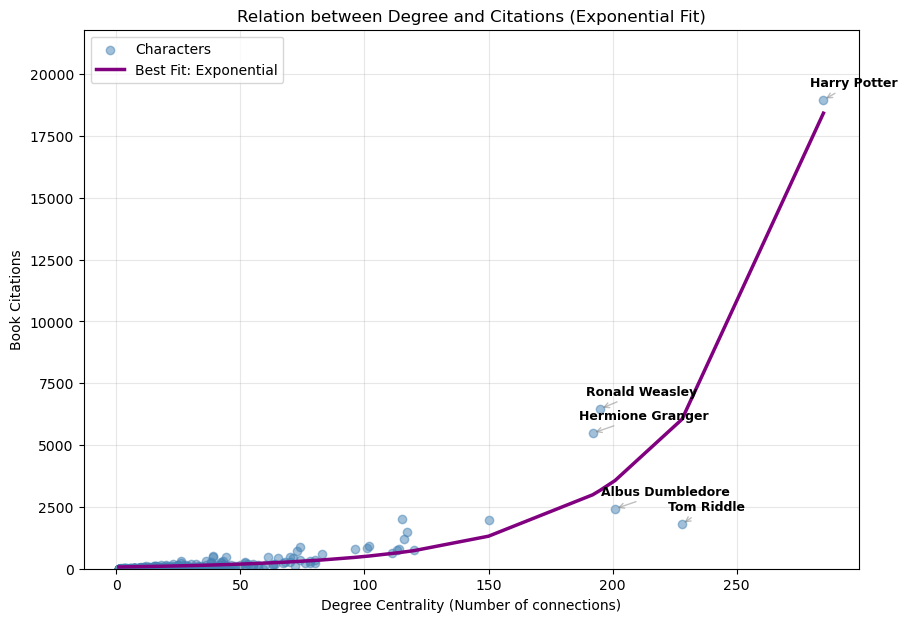

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# 1. Data Preparation
# Sort data by degree to ensure the trend line is plotted smoothly
data_sorted = centrality_df_nonzero.sort_values(by="degree")
x_sorted = data_sorted["degree"].values
y_sorted = data_sorted["citations"].values

# 2. Define the 4 candidate models
def func_linear(x, a, b):
    return a * x + b

def func_poly2(x, a, b, c): 
    # Quadratic (Parabola)
    return a * x**2 + b * x + c

def func_exponential(x, a, b): 
    # Exponential
    return a * np.exp(b * x)

# List of models: (Name, Function, Color for plotting)
models = [
    ("Linear", func_linear, "red"),
    ("Polynomial (deg 2)", func_poly2, "green"),
    ("Exponential", func_exponential, "purple")
]

best_r2 = -np.inf
best_model_info = None 

print("--- Model Comparison Results (Degree) ---")

# 3. Fit and Evaluate all models
for name, func, color in models:
    try:
        # Initial guess (p0) helps the exponential model not to overflow
        p0 = [1, 0.01] if name == "Exponential" else None
        
        # Fit the model
        popt, _ = curve_fit(func, x_sorted, y_sorted, p0=p0, maxfev=10000)
        
        # Predict values
        y_pred = func(x_sorted, *popt)
        
        # Calculate R2 score
        r2 = r2_score(y_sorted, y_pred)
        print(f"Model {name}: R² = {r2:.4f}")
        
        # Check if this is the best model so far
        if r2 > best_r2:
            best_r2 = r2
            # CORRECTION ICI : On ajoute 'popt' dans le tuple sauvegardé
            best_model_info = (name, color, y_pred, popt)

    except Exception as e:
        print(f"Model {name} failed to converge: {e}")

# 4. Extract Results correctly
# CORRECTION ICI : On déballe 4 éléments, dont best_params
best_name, best_color, best_y_pred, best_params = best_model_info

print(f"\n>> The best approximation is: {best_name} with R² = {best_r2:.4f}")

# Dynamic print of parameters and save them globally as a_opt, b_opt, etc.
if len(best_params) == 2:
    a_opt, b_opt = best_params
    print(f">> Parameters recovered: a = {a_opt:.4f}, b = {b_opt:.4f}")
elif len(best_params) == 3:
    a_opt, b_opt, c_opt = best_params
    print(f">> Parameters recovered: a = {a_opt:.4f}, b = {b_opt:.4f}, c = {c_opt:.4f}")

# 5. Plotting
plt.figure(figsize=(10, 7))

# Scatter plot of the actual characters
plt.scatter(centrality_df_nonzero["degree"], centrality_df_nonzero["citations"], 
            alpha=0.5, color="steelblue", label="Characters")

# Plot ONLY the best trend line
plt.plot(x_sorted, best_y_pred, color=best_color, linewidth=2.5, 
         label=f"Best Fit: {best_name}")

# 6. Annotate nodes with degree > 150
for idx, row in centrality_df_nonzero.iterrows():
    if row["degree"] > 150:
        plt.annotate(
            row["character"], 
            (row["degree"], row["citations"]),
            xytext=(-10, 10),           # Offset text slightly
            textcoords='offset points', 
            fontsize=9, 
            fontweight='bold',
            color='black',
            arrowprops=dict(arrowstyle="->", color='gray', alpha=0.5)
        )

# Final formatting
plt.xlabel("Degree Centrality (Number of connections)")
plt.ylabel("Book Citations")
plt.title(f"Relation between Degree and Citations ({best_name} Fit)")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, max(y_sorted) * 1.15) # Add some headroom for labels

plt.show()

In [83]:
# Reuse x, y and exponential parameters a, b from the previous cell
x_full = centrality_df_nonzero["degree"].values
y_full = centrality_df_nonzero["citations"].values

# Predicted citations from the exponential model
y_pred = a_opt * np.exp(b_opt * x_full)

# Avoid division by zero (in practice citations are > 0 for our filtered set)
eps = 1e-9
relative_residual = np.abs(y_full - y_pred) / (y_pred + eps)

centrality_df_nonzero["exp_pred"] = y_pred
centrality_df_nonzero["exp_residual"] = relative_residual

# Characters furthest from the exponential curve
exp_outliers = (
    centrality_df_nonzero
    .sort_values("exp_residual", ascending=False)
    .head(5)
    .loc[:, ["character", "citations", "degree", "exp_pred", "exp_residual"]]
)

exp_outliers.reset_index(drop=True)

,character,citations,degree,exp_pred,exp_residual
0,Vernon Dursley,530,39,150.22,2.53
1,Dudley Dursley,467,39,150.22,2.11
2,Rubeus Hagrid,2024,115,663.76,2.05
3,Remus Lupin,864,74,297.78,1.90
4,Dobby,469,44,165.65,1.83


In [84]:
# On réutilise les données et les paramètres optimaux (a_opt, b_opt) calculés juste avant
x_full = centrality_df_nonzero["degree"].values
y_full = centrality_df_nonzero["citations"].values

# 1. Calcul de la prédiction (Modèle Exponentiel)
y_pred = a_opt * np.exp(b_opt * x_full)

# 2. Calcul du Résidu "Pur" (Différence brute)
# Positif (+) : Le perso a PLUS de citations que prévu (Il est "bavard" ou central pour l'intrigue)
# Négatif (-) : Le perso a MOINS de citations que prévu (Il est "silencieux" malgré ses amis)
raw_residual = y_full - y_pred

centrality_df_nonzero["exp_pred"] = y_pred
centrality_df_nonzero["raw_residual"] = raw_residual

# 3. Tri des plus gros outliers
# On trie par la valeur ABSOLUE de la différence pour voir les plus gros écarts (dans les deux sens)
exp_outliers = (
    centrality_df_nonzero
    .iloc[np.abs(centrality_df_nonzero["raw_residual"].values).argsort()[::-1]] # Tri par magnitude de l'erreur
    .head(10)
    .loc[:, ["character", "citations", "degree", "exp_pred", "raw_residual"]]
)

# Petit formatage pour que ce soit lisible
pd.options.display.float_format = '{:.2f}'.format
exp_outliers.reset_index(drop=True)

,character,citations,degree,exp_pred,raw_residual
0,Tom Riddle,1797,228,6045.42,-4248.42
1,Ronald Weasley,6464,195,3171.34,3292.66
2,Hermione Granger,5486,192,2990.69,2495.31
3,Rubeus Hagrid,2024,115,663.76,1360.24
4,Albus Dumbledore,2421,201,3566.03,-1145.03
5,Sirius Black,1471,117,690.22,780.78
6,Severus Snape,1956,150,1315.75,640.25
7,Remus Lupin,864,74,297.78,566.22
8,Harry Potter,18956,285,18423.86,532.14
9,Draco Malfoy,1198,116,676.86,521.14


### 3.3 Comparaison citation / betweenness-centrality

--- Model Comparison Results (Betweenness) ---
Model Linear: R² = 0.8573
Model Exponential: R² = 0.8144

>> The best approximation is: Linear with R² = 0.8573
>> Parameters recovered: a = 56663.9457, b = -1.6132


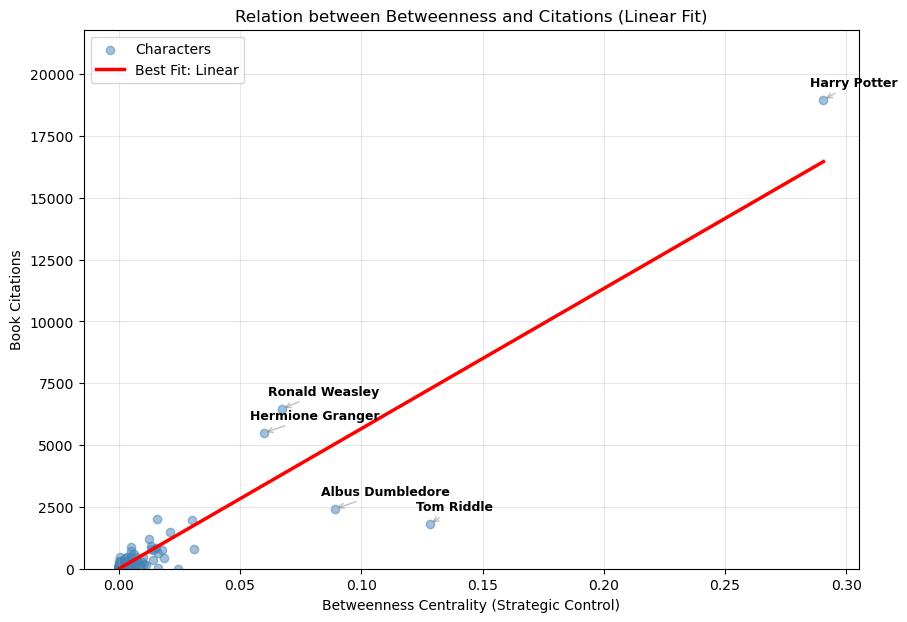

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# 1. Data Preparation
# Sort data by betweenness
data_sorted = centrality_df_nonzero.sort_values(by="betweenness")
x_sorted = data_sorted["betweenness"].values
y_sorted = data_sorted["citations"].values

# 2. Define the 4 candidate models
def func_linear(x, a, b):
    return a * x + b

def func_exponential(x, a, b): 
    return a * np.exp(b * x)

# List of models
models = [
    ("Linear", func_linear, "red"),
    ("Exponential", func_exponential, "purple")
]

best_r2 = -np.inf
best_model_info = None 
# Structure of best_model_info will be: (name, color, y_pred, parameters_popt)

print("--- Model Comparison Results (Betweenness) ---")

# 3. Fit and Evaluate all models
for name, func, color in models:
    try:
        # Initial guess (p0) adjustment for Betweenness (small x values)
        p0 = [1, 10] if name == "Exponential" else None
        
        # Fit the model
        popt, _ = curve_fit(func, x_sorted, y_sorted, p0=p0, maxfev=20000)
        
        # Predict values
        y_pred = func(x_sorted, *popt)
        
        # Calculate R2 score
        r2 = r2_score(y_sorted, y_pred)
        print(f"Model {name}: R² = {r2:.4f}")
        
        # Check if this is the best model so far
        if r2 > best_r2:
            best_r2 = r2
            # WE SAVE THE PARAMETERS (popt) HERE DIRECTLY
            best_model_info = (name, color, y_pred, popt)

    except Exception as e:
        print(f"Model {name} failed to converge: {e}")

# 4. Extract Results for the Winner
best_name, best_color, best_y_pred, best_params = best_model_info

print(f"\n>> The best approximation is: {best_name} with R² = {best_r2:.4f}")

# Dynamic print of parameters (handling a,b vs a,b,c)
if len(best_params) == 2:
    a_opt, b_opt = best_params
    print(f">> Parameters recovered: a = {a_opt:.4f}, b = {b_opt:.4f}")
elif len(best_params) == 3:
    a_opt, b_opt, c_opt = best_params
    print(f">> Parameters recovered: a = {a_opt:.4f}, b = {b_opt:.4f}, c = {c_opt:.4f}")

# 5. Plotting
plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(centrality_df_nonzero["betweenness"], centrality_df_nonzero["citations"], 
            alpha=0.5, color="steelblue", label="Characters")

# Plot ONLY the best trend line
plt.plot(x_sorted, best_y_pred, color=best_color, linewidth=2.5, 
         label=f"Best Fit: {best_name}")

# 6. Annotate strategic nodes (> 0.1 betweenness)
for idx, row in centrality_df_nonzero.iterrows():
    if row["betweenness"] > 0.05: 
        plt.annotate(
            row["character"], 
            (row["betweenness"], row["citations"]),
            xytext=(-10, 10), 
            textcoords='offset points', 
            fontsize=9, 
            fontweight='bold',
            color='black',
            arrowprops=dict(arrowstyle="->", color='gray', alpha=0.5)
        )

# Final formatting
plt.xlabel("Betweenness Centrality (Strategic Control)")
plt.ylabel("Book Citations")
plt.title(f"Relation between Betweenness and Citations ({best_name} Fit)")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, max(y_sorted) * 1.15) 

plt.show()

In [86]:
# Reuse x, y from Betweenness data
x_full = centrality_df_nonzero["betweenness"].values
y_full = centrality_df_nonzero["citations"].values

# 1. Calculate prediction based on the BEST model found previously
# We assume a_opt, b_opt (and c_opt) exist from the previous cell
if best_name == "Exponential":
    y_pred = a_opt * np.exp(b_opt * x_full)
elif best_name == "Polynomial (deg 2)":
    y_pred = a_opt * x_full**2 + b_opt * x_full + c_opt
else: # Linear
    y_pred = a_opt * x_full + b_opt

# 2. Relative Residuals Calculation
# (Difference divided by prediction)
eps = 1e-9
relative_residual = np.abs(y_full - y_pred) / (y_pred + eps)

# Store in specific columns for Betweenness
centrality_df_nonzero["bet_pred"] = y_pred
centrality_df_nonzero["bet_rel_residual"] = relative_residual

# 3. Top Outliers (Relative)
bet_rel_outliers = (
    centrality_df_nonzero
    .sort_values("bet_rel_residual", ascending=False)
    .head(5)
    .loc[:, ["character", "citations", "betweenness", "bet_pred", "bet_rel_residual"]]
)

pd.options.display.float_format = '{:.4f}'.format
bet_rel_outliers.reset_index(drop=True)

,character,citations,betweenness,bet_pred,bet_rel_residual
0,Tofty,10,0.0000,0.0182,549.5197
1,Eileen Prince,8,0.0000,0.0171,465.5172
2,Emmeline Vance,29,0.0000,0.1011,285.8492
3,Dennis Creevey,36,0.0000,0.1975,181.3076
4,Bertha Jorkins,31,0.0000,0.7124,42.5134


In [87]:
# Reuse x, y from Betweenness data
x_full = centrality_df_nonzero["betweenness"].values
y_full = centrality_df_nonzero["citations"].values

# 1. Calculate prediction (same logic as above)
if best_name == "Exponential":
    y_pred = a_opt * np.exp(b_opt * x_full)
elif best_name == "Polynomial (deg 2)":
    y_pred = a_opt * x_full**2 + b_opt * x_full + c_opt
else: # Linear
    y_pred = a_opt * x_full + b_opt

# 2. Raw Residuals Calculation (Real - Predicted)
# Positive = Character talks MORE than their strategic position suggests
# Negative = Character talks LESS than their strategic position suggests
raw_residual = y_full - y_pred

centrality_df_nonzero["bet_pred"] = y_pred
centrality_df_nonzero["bet_raw_residual"] = raw_residual

# 3. Top Outliers (Absolute Magnitude)
# We sort by the absolute size of the error to see the biggest gaps
bet_raw_outliers = (
    centrality_df_nonzero
    .iloc[np.abs(centrality_df_nonzero["bet_raw_residual"].values).argsort()[::-1]] 
    .head(10)
    .loc[:, ["character", "citations", "betweenness", "bet_pred", "bet_raw_residual"]]
)

pd.options.display.float_format = '{:.2f}'.format
bet_raw_outliers.reset_index(drop=True)

,character,citations,betweenness,bet_pred,bet_raw_residual
0,Tom Riddle,1797,0.13,7268.46,-5471.46
1,Ronald Weasley,6464,0.07,3812.21,2651.79
2,Albus Dumbledore,2421,0.09,5047.81,-2626.81
3,Harry Potter,18956,0.29,16465.23,2490.77
4,Hermione Granger,5486,0.06,3381.34,2104.66
5,Moran,2,0.02,1382.10,-1380.10
6,Rubeus Hagrid,2024,0.02,896.16,1127.84
7,Arthur Weasley,780,0.03,1761.57,-981.57
8,Reginald Cattermole,44,0.02,902.30,-858.30
9,Horace Slughorn,432,0.02,1059.19,-627.19


### 3.4 Conclusions

From the 2 previous sibsection we can see that:
* The number of citation in the books evolves exponentially with the degree of a node in the network. This means that the degree of a node in our networks "follows" in general the importance of a character in the books, but it "reduces" it. An extremely important node in term of number of citation still is very important in term of degree in the network but his importance is attenuated.
* The number of citation in the books evolves linearly with the betweenness centrality in the network. These two values evolves together very similarly.

We also learned that the characters being the farest from the approximation curve are very similar for degree and betweenness-centrality:

The nodes being the most under the curves are Tom Riddle (Voldemort) and Albus Dumbledore. This means that these nodes have a very high degree and a very high betweenness centrality in the graph, but not so high number of citation. 
* This clearely makes sense. For Voldemort this is completely clear: most of the time he is called "He Who Must Not Be Named" even if he has a very central role in the story.
* For Dumbledore we can explain it by saying that he is the brigde between almost every of the big parts of the network: his close connexion to the order of phoenix, to Hogward School, to his big family/ friends from when he was younger (from which we know a lot of people during the last book) and to the historical characters (previous hogwarts directors, ...) makes it a very central node. And even if still named a lot, most of the time he is  not in the center of the action. He also dies before the end of the story. This can explain why he has a so big centrality and has less citations than expected.

The nodes being the most over the curve are: Ron, Hermione, Harry and Hagrid. This means that these nodes have a very high number of citaitons but not so high degree and high betweenness centrality.
* For the main trio (Harry, Ron and Hermione): because they are at the center of the story throughout all the books, they have an enormous number of citation (they are the 3 most cited characters). They also are very related and central in the network but not as much as their gigantic number of citation should lead to.
* Hagrid is also a very cited characters, because of its close link to Hagrid. But outside of its link with the trio, Dumbledore, his brother and with some of its animals, we don't know so much of its life. Therefore, he's not so much related and central in the network.

## 4. Dark/Bright side centrality
Can we find out which characters have a central role linking both sides of the line defined by good and evil?

### 4.1 Creation of the evil/good side dictionnary

We will now manually create a dictionnary that maps most important and polarized characters with a label -1,1. The label -1 will be attributed if the character is evil and 1 otherwise. Few things to say:
* characters that were too central such as Harry, Hermione or even "the one who shall not be named" have been on purposely left out since the information gain is very low (everybody points at them).
* most characters have a small role or their position can't be summarized to a simple binary label, for this they won't be included either.


In [16]:
side = {
    "Severus Snape": 1,
    "Rubeus Hagrid": 1,
    "Minerva McGonagall": 1,
    "Draco Malfoy": -1,
    "Ginny Weasley": 1,
    "Arthur Weasley": 1,
    "Molly Weasley": 1,
    "Fred Weasley": 1,
    "George Weasley": 1,
    "Bill Weasley": 1,
    "Charlie Weasley": 1,
    "Filius Flitwick": 1,
    "Pomona Sprout": 1,
    "Sybill Trelawney": 1,
    "Horace Slughorn": 1,
    "Dolores Umbridge": -1,
    "Argus Filch": -1,
    "Poppy Pomfrey": 1,
    "Madam Hooch": 1,
    "Albus Dumbledore": 1,
    "Sirius Black": 1,
    "Remus Lupin": 1,
    "Nymphadora Tonks": 1,
    "Kingsley Shacklebolt": 1,
    "Alastor Moody": 1,
    "Dedalus Diggle": 1,
    "Hestia Jones": 1,
    "Emmeline Vance": 1,
    "Elphias Doge": 1,
    "Arabella Figg": 1,
    "Bellatrix Lestrange": -1,
    "Lucius Malfoy": -1,
    "Narcissa Malfoy": -1,
    "Peter Pettigrew": -1,
    "Bartemius Crouch Junior": -1,
    "Antonin Dolohov": -1,
    "Fenrir Greyback": -1,
    "Walden Macnair": -1,
    "Igor Karkaroff": -1,
    "Alecto Carrow": -1,
    "Amycus Carrow": -1,
    "Travers": -1,
    "Corban Yaxley" : -1,
    "Rabastan Lestrange": -1,
    "Augustus Rookwood": -1,
    "Nott": -1,
    "Evan Rosier": -1,
    "Selwyn": -1,
    "Neville Longbottom": 1,
    "Luna Lovegood": 1,
    "Cho Chang": 1,
    "Cedric Diggory": 1,
    "Dean Thomas": 1,
    "Seamus Finnigan": 1,
    "Colin Creevey": 1,
    "Lee Jordan": 1,
    "Angelina Johnson": 1,
    "Katie Bell": 1,
    "Oliver Wood": 1,
    "Dobby": 1,
    "Kreacher": -1,
    "Fawkes": 1,
    "Buckbeak": 1,
    "Hedwig": 1,
    "Fleur Delacour": 1,
    "Gabrielle Delacour": 1,
    "Aberforth Dumbledore": 1,
    "Gellert Grindelwald": -1,
    "Griphook": -1,
    "Grawp": 1,
    "Nagini": -1
}

### 4.2 Calculating ratios
Some pages have an insignificant amount of links, this could lead to wrong conclusions since to make assumptions a minimum ammount of information is needed. Here we chose to filter out the one linked to less than 6 characters from the side dictionnary that we just built. Also the results are calculated in way that it provides the highest ratio to the characters that have the more balanced distribution (same amount of links towards bad and good people).

In [17]:
import numpy as np
def compute_ambivalence_scores(G, camp):
    filtered_pages = {
        n for n in G.nodes()
        if sum(1 for v in G.neighbors(n) if v in side) > 5
    }
    filtered_pages |= set(side.keys())
    
    
    def get_side(n):
        return side.get(n, 0)  # 1 = good, -1 = bad, 0 = unclear
    
    ambivalence_scores = {}

    for n in G.nodes():
        if n not in filtered_pages:  
            continue
            
        neighbors = list(G.neighbors(n))
        values = [get_side(v) for v in neighbors if get_side(v) != 0]
        if len(values) > 0:
            good = sum(v == 1 for v in values)
            bad = sum(v == -1 for v in values)
            ambivalence = 1 - abs(good - bad) / len(values)
            ambivalence_scores[n] = ambivalence

    sorted_scores = sorted(
        ambivalence_scores.items(),
        key=lambda x: x[1], reverse=True

    )
    return sorted_scores

compute_ambivalence_scores(HpGraph_connected, side)[0:15]

[('Severus Snape', 1.0),
 ('Rabastan Lestrange', 1.0),
 ('Theodore Nott', 1.0),
 ('Xenophilius Lovegood', 1.0),
 ('Griselda Marchbanks', 1.0),
 ('Gibbon', 1.0),
 ('Tom Riddle', 0.9767441860465116),
 ('Bellatrix Lestrange', 0.962962962962963),
 ('Lucius Malfoy', 0.9333333333333333),
 ('Buckbeak', 0.9230769230769231),
 ('Pius Thicknesse', 0.9230769230769231),
 ('Walden Macnair', 0.9230769230769231),
 ('Amycus Carrow', 0.9230769230769231),
 ('Quirinus Quirrell', 0.9230769230769231),
 ('Bartemius Crouch Junior', 0.9090909090909091)]

The results are very interesting, as expected professor Snape occupy a good position (1st here its even better than expected) since in the story he acts like the "mediator" between the dark side (death eaters) and bright side (the order). Otherwise the top of the chart is mostly occupied by death eaters (10/15 without even counting Pius Thicknesse and Quirinus Quirrell which could be good candidates based on their actions), we can try to explain this phenomenon:  
* When you are part of the death eaters, you will be linked to your evil fellows but also to all your ennemies, people that you have killed that are part of the order ect. This explains how Tom Riddle and other evil characters can have such an equilibrated score even though their political beliefs are anything but balanced.

* A normal question would be: yes but why then this logic doesn't apply to character from the order too ?
-> Since the amount of good characters is much more important than evils characters in Harry Potter (at least the well known ones), good characters will end up not being balanced because yes they will have a few ennemies but the amount of friends is too strong so the ratio won't be balanced.

* Few more interesting results: Quirinus Quirrell literally hosts both good and evil in one body which fits beautifully, Xenophilius Lovegood is neutral eccentric who interacts with both sides (supports the Order but betrays Harry once).

In [18]:
compute_ambivalence_scores(HpGraph_connected, side)[-15:]

[('Lucy Weasley', 0.0),
 ('Dominique Weasley', 0.0),
 ('Louis Weasley', 0.0),
 ('Roxanne Weasley', 0.0),
 ('Hugo Granger-Weasley', 0.0),
 ('Lily Potter (II)', 0.0),
 ('Dedalus Diggle', 0.0),
 ('Emmeline Vance', 0.0),
 ('Gellert Grindelwald', 0.0),
 ('Zacharias Smith', 0.0),
 ('Cormac McLaggen', 0.0),
 ('Gabrielle Delacour', 0.0),
 ('Muriel', 0.0),
 ('Hestia Jones', 0.0),
 ('Trevor', 0.0)]

Let's now give a look at the most unbalanced results. We can see all this new generation of Weasley kids and other characters such as Trevor or Zacharias Smith that have never been confronted to the darkforces but still know various persons from the brigth side. We also have a few surprising results such as the presence of Grindelwald which should follow the rule stated before explaining dark wizard centralities. However after further verification, this is because he is only linked to good characters of our present, and that the dark wizards of his time aren't specified in our side dictionnary (because no major importance in Harry's story).

## 5. Hogward houses text

In this section we will try awnser 2 questions:
* Which are the most "positive" houses?
* Does the mostly used/ most specific vocabulary used in the wikipages belonging to this house reflects the "values" of the each house?

### 5.1 Finding the houses

First, we need to find the Hogward houses of each characters that belongs to one. To do so, we look at the wikipedia infobox of each character and at the "house" line.

In [19]:
# definition of function to get the house of a character, knowing its fandom wikipedia page

import re
import requests

def get_full_infobox(text):
    """
    Gets the full content fo the infobox by dealing with the interlocking {{...{{...}}...}}
    """
    start_marker = "{{Individual infobox"
    start_index = text.find(start_marker)
    
    if start_index == -1:
        return None
    
    # We start counting after the opening marker
    current_index = start_index
    brace_count = 0
    found_first_open = False
    
    # We go through the text char by char
    # we look for the closing corresponding to the first {{
    for i in range(start_index, len(text)):
        # we look for both char at a time to find {{ or }}
        chunk = text[i:i+2]
        
        if chunk == '{{':
            brace_count += 1
            found_first_open = True
        elif chunk == '}}':
            brace_count -= 1
            
        # If we opened curly braces and returned to 0, that's the end of the infobox.
        if found_first_open and brace_count == 0:
            # We return the entire block (+2 to include the final }}
            return text[start_index:i+2]
            
    return None

def extract_house(file_content):
    """
    Extracts the house only if it is formatted as a wiki link [...]
    """
    
    infobox_content = get_full_infobox(file_content)
    
    if not infobox_content:
        return None

    house_match = re.search(
        r'\|\s*house\s*=\s*\[\[([^|\]]+)', 
        infobox_content, 
        re.IGNORECASE
    )
    
    if house_match:
        return house_match.group(1).strip()
    
    return None

In [20]:
# we construct a dict characters -> house that will be useful

characters_houses = dict()

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
        house = extract_house(content)
        
        if house:
            characters_houses[name_clean] = house

In [21]:
# we print the number of citations for each house

from collections import Counter

all_houses = list(characters_houses.values())

house_counts = Counter(all_houses)

print(f"\n--- Number of characters in each houses (Total: {len(characters_houses)}) ---")

for house, count in house_counts.most_common():
    print(f"{house:<15} : {count}")


--- Number of characters in each houses (Total: 151) ---
Gryffindor      : 54
Slytherin       : 48
Ravenclaw       : 27
Hufflepuff      : 22


As we can see, only 151 out of the 387 characters have a hogward house. Other peaples have none either because their are not well known enough and we don't know their house, because they are wizards that comes from other magic schools or they are not wizards (muggles, fantastic beast, animals, ...).

In this part, we will only keep the nodes that have a house (in ***HpHouseGraph***)

In [22]:
# we create the graph containing only the characters that have a house

import networkx as nx

nodes_to_keep = list(characters_houses.keys())

# we create a new graph : HpHouseGraph that keeps only the nodes that belongs to a house.
HpHouseGraph = HpGraph_undir.subgraph(nodes_to_keep).copy()

# in this graph, the nodes have a new attribute: house
nx.set_node_attributes(HpHouseGraph, characters_houses, name="house")

print(f"Original Graph : {HpGraph_undir.number_of_nodes()} nodes, {HpGraph_undir.number_of_edges()} links.")
print(f"New Graph (House only) : {HpHouseGraph.number_of_nodes()} nodes, {HpHouseGraph.number_of_edges()} links.")

Original Graph : 387 nodes, 4622 links.
New Graph (House only) : 143 nodes, 2035 links.


In [23]:
# we construct the dictionary: house -> set(characters)
house_to_character = {}
for character in HpHouseGraph.nodes():
    house = characters_houses[character]

    if(house not in house_to_character.keys()):
        house_to_character[house] = set()

    house_to_character[house].add(character)

### 5.2 Sentiments of houses

In [24]:
# ----- function that calculates sentiment given a list of tokens -----

import os
from nltk.probability import FreqDist
import requests
import io

def load_labmt_scores():
    """
    Loads happiness scores from the labMT file hosted on GitHub.

    The file is expected to be a tab-delimited .txt file,
    where the first column is the word and the third is the average happiness score.
    This function skips the first two header lines.

    Returns:
        dict: A dictionary mapping {word: happiness_score}.
              Returns an empty dictionary if the file cannot be fetched or processed.
    """
    GITHUB_URL = "https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/labMT%201.0.txt"
    word_scores = {}
    
    try:
        response = requests.get(GITHUB_URL)
        response.raise_for_status() 

        # deal the text content line by line
        lines = response.text.splitlines()
        
        # minimal verification for the two first lines
        if len(lines) < 2:
             print("Error: The fetched file content is too short (less than 2 header lines).")
             return {}

        # Skip the two first lines
        data_lines = lines[2:]

        # read each data line
        for line in data_lines:
            try:
                parts = line.strip().split('\t')
                
                # check there is at least 3 columns
                if len(parts) >= 3:
                    word = parts[0]
                    # the score column is the thirs (0, 1, 2)
                    happiness_score = float(parts[2]) 
                    word_scores[word] = happiness_score
                    
            except (ValueError, IndexError):
                continue
                
    except requests.exceptions.RequestException as e:
        print(f"Error: Could not fetch the file from {GITHUB_URL}. Details: {e}")
        return {}
    except Exception as e:
        print(f"An unexpected error occurred during processing: {e}")
        return {}
            
    return word_scores

def calculate_sentiment(tokens, word_scores):
    """
    Calculates the average sentiment score for a list of tokens
    using the optimized FreqDist method.

    Args:
        tokens (list): A list of all word strings (lowercase).
        word_scores (dict): The {word: score} lexicon.

    Returns:
        float or None: The average sentiment score, or None if no
                       matching words were found.
    """
    if not tokens:
        return None
    
    # get counts for each unique token
    token_counts = FreqDist(tokens)
    
    total_score = 0
    total_word_count = 0
    
    # iterate over UNIQUE words and apply weighted mean
    for word, count in token_counts.items():
        score = word_scores.get(word)
        if score is not None:
            # This is the weighted mean calculation
            total_score += score * count
            total_word_count += count

    # Avoid division by zero if no words were found in the lexicon
    if total_word_count == 0:
        return None

    return total_score / total_word_count

In [25]:
# ----- iterate over nodes in wiki network and calculate sentiment for every page -----

import requests
import networkx as nx

# load the sentiment lexicon
print("Loading labMT sentiment lexicon...")
labmt_scores = load_labmt_scores()

if not labmt_scores:
    print("Sentiment lexicon could not be loaded. Halting script.")
else:
    print(f"Successfully loaded {len(labmt_scores)} sentiment scores.")
    
    sentiments_dict = {}
    total_nodes = len(HpHouseGraph.nodes())

    print(f"\nStarting sentiment calculation for {total_nodes} nodes...")

    raw_to_formatted = dict(zip(names_clean, names)) # Ex: raw_to_clean["Harry Potter"] -> "Harry_Potter"
    
    # iterate over every node in the graph
    for i, node in enumerate(HpHouseGraph.nodes()):
        name_formatted = raw_to_formatted[node]
        name_url = raw_to_url[name_formatted]
        
        # fetch the content for each node
        url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
        sentiment = None # Default value
        
        try:
            response = requests.get(url)
            response.raise_for_status()  # check for HTTP errors (like 404)
            content = response.text
            
            # tokenize the page content
            tokens = [word.lower() for word in re.findall(r'\b\w+\b', content)]
            
            # calculate sentiment using the function
            sentiment = calculate_sentiment(tokens, labmt_scores)
            
        except requests.exceptions.RequestException as e:
            print(f"Warning: Could not fetch content for {node}. Error: {e}")
        
        # store the result (either the score or None)
        sentiments_dict[node] = sentiment

    # add all collected sentiments to the graph as a new node attribute
    nx.set_node_attributes(HpHouseGraph, sentiments_dict, 'sentiment')

Loading labMT sentiment lexicon...
Successfully loaded 10230 sentiment scores.

Starting sentiment calculation for 143 nodes...


In [26]:
# ----- Calculate the average sentiment across all the pages. Also calculate the variance and 50th percentile -----

import numpy as np

# Extract all sentiment values directly from the dictionary
sentiment_values = sentiments_dict.values()

# Filter out all 'None' values (for pages that failed or had no matched words)
valid_sentiments = [score for score in sentiment_values if score is not None]

if valid_sentiments:
    sentiment_array = np.array(valid_sentiments)
    
    # Calculate the statistics
    average_sentiment = np.mean(sentiment_array)
    variance_sentiment = np.var(sentiment_array)
    percentile_25 = np.percentile(sentiment_array, 25)
    percentile_75 = np.percentile(sentiment_array, 75)

    
    # Print the results
    print(f"--- Sentiment Statistics Across {len(valid_sentiments)} Pages ---")
    print(f"Average Sentiment (Mean):   {average_sentiment:.4f}")
    print(f"Variance:                   {variance_sentiment:.4f}")
    print(f"25th Percentile:            {percentile_25:.4f}")
    print(f"75th Percentile:            {percentile_75:.4f}")
    
else:
    print("No valid sentiment scores were found to calculate statistics.")

--- Sentiment Statistics Across 143 Pages ---
Average Sentiment (Mean):   5.3603
Variance:                   0.0070
25th Percentile:            5.3110
75th Percentile:            5.3992


In [27]:
# Calculate the average sentiment for this house: each member of the app has the same weight

for i, house in enumerate(house_to_character.keys()):
    house_total_score = 0
    
    for node in house_to_character[house]:
        score = sentiments_dict.get(node) # get score from our original dictionary
        house_total_score += score        
    
    avg_sentiment = house_total_score / len(house_to_character[house])
    print(f"{house} average sentiment: {avg_sentiment:.4f}")

Ravenclaw average sentiment: 5.3756
Slytherin average sentiment: 5.3348
Gryffindor average sentiment: 5.3723
Hufflepuff average sentiment: 5.3704


### 5.3 TF-IDF for Houses

In [28]:
# Function to compute the TF

import nltk
import string
from nltk.corpus import stopwords

def find_words_per_characters(more_stop_words):
    punctuation_marks = set(string.punctuation) 
    stop_words = set(stopwords.words('english')) # we took the liberty to also filter the stopwords to have some more interessting results
    
    # we loop through every wiki-pages (/ characterss) and construct the TF per pages in content_dict 
    content_dict = {}
    
    for name in name_set:
        name_clean = raw_to_clean[name]
        name_url = raw_to_url[name]
        
        url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
        response = requests.get(url)
            
        if response.status_code == 200:
            content = response.text
    
            if not content.strip():
                continue
    
            # tokenize the pages 
            tokenized_content = nltk.word_tokenize(content)
    
            # Remove all punctuation from your list of tokens
            filtered_tokens = [
                token for token in tokenized_content
                if token not in punctuation_marks and token.lower() not in stop_words and token.lower() not in more_stop_words
            ]
    
            # Set everything to lower case
            lower_tokens = [token.lower() for token in filtered_tokens]
    
            # Lemmatize your words
            wnl = nltk.WordNetLemmatizer()
            lemmatized_tokens = [wnl.lemmatize(token) for token in lower_tokens]
    
            # I already transform the list of tokens into a list of dict. token --> nb of iteration
            # This is basically the TF of each wiki-page
            token_counts = {} 
            for token in lemmatized_tokens:
                if token in token_counts:
                    token_counts[token] += 1
                else:
                       token_counts[token] = 1
    
            # we filter out rare words
            frequent_tokens_dict = {token: count for token, count in token_counts.items() if count >= 5}
            
            content_dict[name_clean] = frequent_tokens_dict

    return content_dict

In [29]:
# Function to construct the houses' TF by adding in a house all the characters that belongs to this house 

def compute_houses_TF(words_dict):
    houses_TF = {}
    
    for house in set(all_houses):
        # we iterate on all the characters that have this house
        houses_TF[house] = {}
        
        characters_in_house = house_to_character[house]
        for character in characters_in_house:
            if character not in words_dict: # security stuff
                continue 
            # we iterate on all tokens in the character's associated wiki-page
            for token, iterations in words_dict[character].items():            
                # we add the iterations of the token in the correct dict
                specific_house_TF = houses_TF[house]
                if token not in specific_house_TF.keys():
                    specific_house_TF[token] = iterations
                else:
                    specific_house_TF[token] += iterations
    
    # we print the houses' TF in a nice way
    for house, tf_dict in houses_TF.items():
        sorted_tf = sorted(tf_dict.items(), key=lambda x: x[1], reverse=True)
        top15 = sorted_tf[:15]
        print(f"Top 15 words for {house}:")
        for word, count in top15:
            print(f"{word}: {count}")
        print()

    return houses_TF

In [30]:
# Computes the TF for the houses
more_punctuation_and_stop_words = {"''", "``", "ref", "/ref", "name=", "category", "'s", "also", "hbp12", "hbp19"}
content_dict = find_words_per_characters(more_punctuation_and_stop_words)
houses_TF = compute_houses_TF(content_dict)

Top 15 words for Ravenclaw:
harry: 972
potter: 629
hogwarts: 590
luna: 486
school: 434
year: 405
file: 374
lockhart: 374
student: 360
ravenclaw: 345
flitwick: 290
dumbledore: 282
one: 276
cho: 264
trelawney: 261

Top 15 words for Hufflepuff:
newt: 589
harry: 563
hogwarts: 461
potter: 368
tonks: 350
year: 319
dumbledore: 295
file: 281
school: 270
cedric: 266
hufflepuff: 254
sprout: 210
one: 178
grindelwald: 178
would: 177

Top 15 words for Gryffindor:
harry: 6877
potter: 3377
dumbledore: 2653
hogwarts: 2443
hermione: 2340
ron: 2192
weasley: 1964
year: 1826
file: 1745
would: 1401
voldemort: 1399
school: 1374
first: 1193
sirius: 1175
death: 1147

Top 15 words for Slytherin:
harry: 1886
voldemort: 1744
potter: 1401
snape: 1232
hogwarts: 1158
death: 980
draco: 942
malfoy: 794
dumbledore: 763
year: 750
slytherin: 725
eater: 698
would: 656
school: 647
file: 628



In [31]:
# Function to compute the TF-IDF

from math import log
from collections import defaultdict


def compute_houses_TFIDF(houses_TF):
    # ---- First we compute the IDF ----- 
    total_houses = len(houses_TF)
    
    word_in_house = defaultdict(int) # for each words, counts the #houses it is in
    for house, tf_dict in houses_TF.items():
        for word in tf_dict.keys():
            word_in_house[word] += 1
    
    idf_dict = {word: log(total_houses / count) for word, count in word_in_house.items()}
    
    # ----- We compute the TF-IDF -----
    tfidf_scores = {}
    for house, tf_dict in houses_TF.items():
        tfidf_scores[house] = {}
        for word, tf in tf_dict.items():
            log_tf = log(1 + tf)
            tfidf_scores[house][word] = log_tf * idf_dict[word]
    
    # ----- We list the Top5 TF-IDF words for each house -----
    for house in tfidf_scores:
        sorted_tfidf = sorted(tfidf_scores[house].items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"\nTop 5 words for **{house}** (TF-IDF) :")
        for word, score in sorted_tfidf:
            print(f"  - {word} ({score:.3f})")

    return tfidf_scores

In [32]:
# And now we compute the TF-IDF for our houses

tfidf_scores = compute_houses_TFIDF(houses_TF)


Top 5 words for **Ravenclaw** (TF-IDF) :
  - terry (5.395)
  - roger (5.277)
  - anthony (5.214)
  - davy (5.148)
  - quibbler (5.079)

Top 5 words for **Hufflepuff** (TF-IDF) :
  - tina (6.715)
  - susan (6.298)
  - kettleburn (6.004)
  - queenie (5.676)
  - macmillan (5.114)

Top 5 words for **Gryffindor** (TF-IDF) :
  - angelina (7.317)
  - charlie (7.128)
  - oliver (6.909)
  - colin (6.860)
  - map (6.614)

Top 5 words for **Slytherin** (TF-IDF) :
  - avery (6.284)
  - rodolphus (6.269)
  - squad (6.004)
  - inquisitorial (5.929)
  - flint (5.909)


By doing so, for each house we basically get the 10 popular characters from each houses as the words with the highest TF-IDF. This is interessting, because the 10 characters chosen are not always the most popoular ones. For Ravenclaw we would expect Luna Lovegood or Cho Chang to be there, for Slitherin we would expect Draco, for Gryffindor we would expect Harry, Ron and Hermione and for Hufflepuff we would expect Cedric Diggory. But none of them are in the top.10 of words with highest TF-IDF words. This reinforce we fealing we already has that very important characters in the story are generally very central in the network and cited in a lot of other pages, includnig the one other houses characters. Thus, their name are not really "specific" to their house and they are not present in the TF-IDF highest rank.

But it does not really help us to awnser our question: can we guess the houses values from the TF-IDF. So, we will now filter all the character's names of the peoples belining to these houses.

In [33]:
# we compute the TF and TF-IDF by filtering most of the characters first names, surname, secondname, ...

more_stop_words_including_names = {"''", "``", "|-", "style=", "ref", "/ref", "name=", "category", "'s", "also", "hbp12", "hbp19", "pottermorebio", "file", "ps17", "ps5", "cos16",
                                   "harry", "potter", "lockhart", "flitwick", "trelawney", "cho", "dumbledore", "malfoy", "black", "voldemort", "bellatrix", "albus", "draco", "hermione", "molly", "weasley", "james", "lily", "remus", "tonks", "cedric", "grindelwald", "jacob", "goyle", "scorpius", "pettigrew", "ron", "sirius", "scamander", "hannah",  
                                   "quirrell", "myrtle", "ollivander", "marietta", "michael", "xenophilius", "terry", "roger", "anthony", "belby", "quirinus", "garrick", "edgecombe", "bagnold", "davy", "snape", "hagrid", "luna", "dursley", "c", "kowalski", "hengist", 
                                   "lucius", "kreacher", "crabbe", "narcissa", "regulus", "pansy", "rodolphus", "avery", "walburga", "blaise", "amycus", "flint", "rosier", "delphi", "rabastan", "phineas", "nigellus", "nott", "scabior", "parkinson", "vincent", "mulciber", "black|black", "greengrass", "gregory", "montague", "hbp2", "theodore", "astoria", "ps11", "carrow", "warrington", "bft", "bulstrode", "zabini", "gof30", "alice", "frank", "bletchley", "dh23", "bole", "ootp6", "evan", "daphne",  
                                   "dean", "angelina", "charlie", "colin", "lee", "oliver", "alicia", "thomas", "mclaggen", "jordan", "dennis", "creevey", "celestina", "evans", "scabbers", "johnson", "warbeck", "ariana", "prewett", "finnigan", "hbp11", "petunia", "cormac", 
                                   "newt", "tina", "justin", "theseus", "susan", "kettleburn", "leta", "smith", "abbott", "newton", "queenie", "macmillan", "silvanus", "zacharias", "finch-fletchley", "fb", "yusuf", "uric", "neville", "granger", "arthur", "ginny", "percy", "fred", "umbridge", "minerva", "tom", "ronald", "george", "teddy", "diggory", "lupin", "pomona", "lovegood", "padma", "gilderoy", "leanne", "severus", "slughorn", "riddle", 
                                  "delphini", "burke", "malfoys", "dh13", "adrian", "'tom", "|tom", "poa15", "white-space", "merope", "|voldemort", "pucey", "pottermoreprofile", "lucian", "lestrange|bellatrix", "malfoy|draco", "hpb22", "|bellatrix", "cassandra", "dh24", "ollivanders", "cos4", "gof16", "ootp23", "lisa", "graf", "kama", "ernie"}
content_dict = find_words_per_characters(more_stop_words_including_names)
houses_TF = compute_houses_TF(content_dict)
tfidf_scores = compute_houses_TFIDF(houses_TF)

KeyboardInterrupt: 

In [ ]:
# we display the wordclouds for the TF's of the houses after filtering names

from wordcloud import WordCloud
import matplotlib.pyplot as plt

for house in set(all_houses):
    tf_dict = houses_TF[house]
    wordcloud = WordCloud(width=400, height=200, background_color='white', collocations=False).generate_from_frequencies(tf_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {house}")
    plt.show()

In [ ]:
# we display the wordclouds for the TF-IDF's of the houses after filtering names

for house in tfidf_scores:
    # extract the scores for this house
    scores = list(tfidf_scores[house].values())

    # Find the min and the max
    min_score = min(scores)
    max_score = max(scores)

    # Normalized the score bewteen 1 and 100 
    normalized_scores = {}
    for word, score in tfidf_scores[house].items():
        if max_score != min_score:
            normalized_scores[word] = 1 + (score - min_score) * 99 / (max_score - min_score)
        else:
            normalized_scores[word] = 1  # if scores are identical

    # creates the wordclouds
    wordcloud = WordCloud(
        width=400,
        height=200,
        background_color='white',
        collocations=False
    ).generate_from_frequencies(normalized_scores)

    # display the wordclouds
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {house} (TF-IDF)")
    plt.show()

Conclusion:

TF-IDF really makes the names of the "small" characters from the houses being very important (since their names are written multiple times in the page of the concerned character. And after a long filtering of names, the result is not really convincing. We end up with TF-IDF rankings which mainly contain nouns specific to certain important characters of that house.

However, when looking at the TFs, after filtering the names, we get better results.
* For Ravenclaw, words like school, student or professor are particullarly high, which evokes the intelligence and learning values of the house.
* For Slitherin, words like "death", "eater", "dark", "battle" are particularly high, which evokes their ambissius, cunning values
* For Giffindor, words like "family", "first", "order", "battle", "friends" are high, this evokes the bravery and "defender of the good" values associated to this house
* For Hufflepuff, words like "student", "house" or "family" are high and make us think on their "kindness" value (even if this is less clear for this house).

But still, these results are not really clear. This makes us think that, knowing their wikipedia pages, there is no close link within the houses. But is that really true? To awnser this question, we will in the next section try to see if houses form good communities in the network.

## 6. Communities

### 6.1 Louvain communities on the hole network

First, we want to know if having strong communities is even possible on our graph. For that we use the Louvain algorithm.

In [ ]:
# Function that computes the modularity of a comminity separation

def modularity(G, communities):
    # The number of link L in the graph
    L = len(G.edges())
    # the number of communities
    n_c = len(communities)
    # the number of links in each community L_c
    L_c = [0] * n_c
    # The sum of degrees of the nodes in each communities
    k_c = [0] * n_c
    
    for i in range(0,len(communities)):
        community = communities[i]

        # Compute k_c
        for node in community:
            k_c[i] += G.degree[node]

    # Compute L_c
    for i, community in enumerate(communities):
        for node1, node2 in G.edges():
            if node1 in community and node2 in community:
                L_c[i] += 1
    
    M = 0
    for c in range(n_c):
        M += L_c[c] / L - pow(k_c[c] / (2 * L), 2)
    return M

In [ ]:
# compute the modularity of the Louvain algorithm's communities.

from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpGraph_undir, seed=1)

M_louvain = modularity(HpGraph_undir, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

The Louvain communities are not good enougth (< 0.3). We also saw in part.3 that some set of nodes have a very high betweenness centrality, relates to a lot of nodes and to most of the communities. This makes the communities become very weaker. Let's try to delete the 20 nodes with the highest betweenness centrality to see if on this network we can find stronger communities.

### 6.2 Louvain without the betweenness hubs

In [ ]:
# This cell is not useful, it does just print the top.20 betweenness nodes of the network to see which nodes are conserned.

import networkx as nx

# computer the betweenness centrality of all the nodes
betweenness_centrality = nx.betweenness_centrality(HpGraph_undir)

# display the 20 first nodes
top_20_intermediaries = sorted(
    betweenness_centrality.items(), 
    key=lambda item: item[1], 
    reverse=True
)[:20]

print("--- Top 20 of the betweenness centrality nodes ---")
for node, score in top_20_intermediaries:
    # the score is between 0 and 1 (normalized)
    print(f"{node}: {score:.4f}")

In [ ]:
N_TOP_NODES = 20

# compute the betweenness centrality
betweenness_centrality = nx.betweenness_centrality(HpGraph_undir)

# sort the nodes by sdecreasing score and identify the top N
sorted_nodes_by_betweenness = sorted(
    betweenness_centrality.items(), 
    key=lambda item: item[1], 
    reverse=True
)

# extract the names of the top N nodes
nodes_to_remove_list = [node for node, score in sorted_nodes_by_betweenness[:N_TOP_NODES]]

# Create a new version of the graph without these nodes
HpGraph_debridged = HpGraph_undir.copy()
HpGraph_debridged.remove_nodes_from(nodes_to_remove_list)


# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.connected_components(HpGraph_debridged))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_debridged = HpGraph_debridged.subgraph(largest_component).copy()
else:
    HpGraph_debridged = HpGraph_debridged.copy()


# Display information about the graph
print(f"\n--- After deletion ---")
print(f"Orginial graph (nodes/edges) : {HpGraph_undir.number_of_nodes()} / {HpGraph_undir.number_of_edges()}")
print(f"New graph 'HpGraph_debridged' (nodes/edges) : {HpGraph_debridged.number_of_nodes()} / {HpGraph_debridged.number_of_edges()}")

In [ ]:
# Compute the Louvain on the reduces graph

from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpGraph_debridged, seed=10)

M_louvain = modularity(HpGraph_debridged, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

With the debridged graph, Louvain gives strong communities. This means with this graph, 

In [ ]:
# Displays the Louvain communities on the debridged graph

import matplotlib.pyplot as plt
import numpy as np

def color_choice(louvain_commu):
    # --- Select the biggest communities ---
    sorted_comms = sorted(louvain_commu, key=len, reverse=True)
    top_k = 10  # on garde les 10 plus grandes
    top_comms = sorted_comms[:top_k]
    
    # creation of a mapping node -> couleur
    color_map = {}
    colors = plt.cm.tab10.colors
    for i, comm in enumerate(top_comms):
        for node in comm:
            color_map[node] = colors[i % len(colors)]
    
    for comm in sorted_comms[top_k:]:
        for node in comm:
            color_map[node] = (0.8, 0.8, 0.8)

    return color_map

# --- size of the nodes proportional to the degree ---
node_sizes = [HpGraph_debridged.degree(n) for n in HpGraph_debridged.nodes()]

# --- positionning with ForceAtlas2 ---
pos = nx.forceatlas2_layout(
    HpGraph_debridged,
    max_iter=300,
    scaling_ratio=1.0,
    gravity=1.0,
    jitter_tolerance=1.0
)

# --- color of the nodes ---
color_map = color_choice(louvain_commu)
node_colors = [color_map[n] for n in HpGraph_debridged.nodes()]

# --- Displaying ---
plt.figure(figsize=(15, 15))
nx.draw_networkx_edges(HpGraph_debridged, pos, alpha=0.15, width=0.4, edge_color="black")
nx.draw_networkx_nodes(
    HpGraph_debridged, pos,
    node_size=node_sizes,
    node_color=node_colors
)

plt.title("Wikipedia Rock Bands Network — ForceAtlas2 Layout\nColors = Louvain structural communities", fontsize=14)
plt.axis("off")
plt.show()

### 6.3 Houses as communities

#### 6.3.1 Houses graph without the betweenness hubs

In [ ]:
# Create a new version of the house graph without the top bewteenness nodes

HpHouseGraph_debridged = HpHouseGraph.copy()
HpHouseGraph_debridged.remove_nodes_from(nodes_to_remove_list)


# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.connected_components(HpHouseGraph_debridged))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_debrHpHouseGraph_debridgedidged = HpHouseGraph_debridged.subgraph(largest_component).copy()
else:
    HpHouseGraph_debridged = HpHouseGraph_debridged.copy()


# Displays informations about the new graph
print(f"\n--- After deletion ---")
print(f"Original graph (nodes/edges) : {HpHouseGraph.number_of_nodes()} / {HpHouseGraph.number_of_edges()}")
print(f"New Graph 'HpHouseGraph_debridged' (nodes/edges) : {HpHouseGraph_debridged.number_of_nodes()} / {HpHouseGraph_debridged.number_of_edges()}")

#### 6.3.2 Houses as communities

In [ ]:
# Modularity for the house-communities

characters_in_debridged_graph = set(HpHouseGraph_debridged.nodes())
house_to_character_debridged = {}
for house, characters_set in house_to_character.items():
    filtered_characters = characters_set & characters_in_debridged_graph
    if filtered_characters:
        house_to_character_debridged[house] = filtered_characters

M = modularity(HpHouseGraph_debridged, list(house_to_character_debridged.values()))
print(M)

In [ ]:
# Recompute the Louvain on the reduces graph to enshure Louvain still gives good communities on this reduced graph

from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpHouseGraph_debridged, seed=2)

M_louvain = modularity(HpHouseGraph_debridged, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

### 6.4 Blood-Status as communities

#### 6.4.1 Finding the Blood-Status

##### 6.4.1.1 Total blood-status graph

In [ ]:
# Function to extract the species and blood-status of each character, knowing their wikitext

def extract_species(file_content):
    """
    Extracts the species only if it is formatted as a wiki link [...]
    """
    
    infobox_content = get_full_infobox(file_content)
    
    if not infobox_content:
        return None

    species_match = re.search(
        r'\|\s*species\s*=\s*\[\[([^|\]]+)', 
        infobox_content, 
        re.IGNORECASE
    )
    
    if species_match:
        return species_match.group(1).strip()
    
    return None


# Blood
def extract_blood(file_content):
    """
    Extracts the blood-status only if it is formatted as a wiki link [...]
    """
    
    infobox_content = get_full_infobox(file_content)
    
    if not infobox_content:
        return None

    blood_match = re.search(
        r'\|\s*blood\s*=\s*\[\[([^|\]]+)', 
        infobox_content, 
        re.IGNORECASE
    )
    
    if blood_match:
        return blood_match.group(1).strip()
    
    return None

In [ ]:
# creates and fill the character -> species and character -> blood dictionaries (they will be useful after)

characters_species = dict()
characters_blood = dict()

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
        species = extract_species(content)
        blood = extract_blood(content)
        
        if species:
            characters_species[name_clean] = species
        if blood and species == "Human":
            characters_blood[name_clean] = blood

In [ ]:
# prints the number character that belongs to each species and blood-status. Only humans for which we know the blood-status have a blood-status.

from collections import Counter

all_species = list(characters_species.values())
all_bloods = list(characters_blood.values())

species_counts = Counter(all_species)
blood_counts = Counter(all_bloods)

print(f"\n--- Number of characters from each species (Total: {len(characters_species)}) ---")
for species, count in species_counts.most_common():
    print(f"{species:<15} : {count}")

print(f"\n--- Number of characters from each blood-status (Total: {len(characters_blood)}) ---")
for blood, count in blood_counts.most_common():
    print(f"{blood:<15} : {count}")

In [ ]:
# creates the graph containing only the nodes that are not human and the human one that have a blood-status.

import networkx as nx

# we only keep the nodes that either "are not human" or "are human and have a known blood-status"
all_nodes_with_species = characters_species.keys()
all_nodes_with_blood_status = set(characters_blood.keys())
nodes_to_keep = [
    node for node in all_nodes_with_species
    if not (characters_species[node] == "Human" and node not in all_nodes_with_blood_status)
]

# we create a new graph : HpBloodGraph that keeps only the nodes that belongs to a house.
HpBloodGraph = HpGraph_undir.subgraph(nodes_to_keep).copy()

# in this graph, the nodes have new attribute: species and blood
nx.set_node_attributes(HpBloodGraph, characters_species, name="species")
nx.set_node_attributes(HpBloodGraph, characters_blood, name="blood")

print(f"Original Graph : {HpGraph_undir.number_of_nodes()} nodes, {HpGraph_undir.number_of_edges()} links.")
print(f"New Graph (House only) : {HpBloodGraph.number_of_nodes()} nodes, {HpBloodGraph.number_of_edges()} links.")

##### 6.4.1.2 Blood-status graph without the betweenness hubs

In [ ]:
# Create a new verison of our graph without the top bewteenness characters

HpBloodGraph_debridged = HpBloodGraph.copy()
HpBloodGraph_debridged.remove_nodes_from(nodes_to_remove_list)

# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.connected_components(HpBloodGraph_debridged))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpBloodGraph_debridged = HpBloodGraph_debridged.subgraph(largest_component).copy()
else:
    HpBloodGraph_debridged = HpBloodGraph_debridged.copy()


# Display the information about the graph
print(f"\n--- After Deletion ---")
print(f"Original graph (nodes/edges) : {HpBloodGraph.number_of_nodes()} / {HpBloodGraph.number_of_edges()}")
print(f"New graph 'HpBloodGraph_debridged' (nodes/edges) : {HpBloodGraph_debridged.number_of_nodes()} / {HpBloodGraph_debridged.number_of_edges()}")

#### 6.4.2 Blood-Status as communities

In [ ]:
# we need to construct the dictionary: blood-status -> set(characters)
# The non-human characters are said to have the same "blood-status" if they belong to the same species.
blood_to_character = {}
for character in HpBloodGraph_debridged.nodes():
    species = characters_species[character]

    if species != "Human":
        if species not in blood_to_character.keys():
           blood_to_character[species] = set()
        blood_to_character[species].add(character)

    else:
        blood = characters_blood[character]
        if blood not in blood_to_character.keys():
            blood_to_character[blood] = set()
        blood_to_character[blood].add(character)

# Modularity for the blood-communities
M = modularity(HpBloodGraph_debridged, list(blood_to_character.values()))
print(M)

In [ ]:
# Recompute the Louvain on the reduces graph to enshure Louvain still gives good communities on this reduced graph
from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpBloodGraph_debridged, seed=2)

M_louvain = modularity(HpBloodGraph_debridged, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

### 6.5 What are the Louvain Communities

Here we are going to explain how Louvain splitt the network and what the "real" communities look like.

In [ ]:
# print the characters contained in each one of the communities

print("\n--- Communities details ---")

for i, community in enumerate(louvain_commu, 1):
    membres = sorted(list(community))
    
    print(f"Community {i} ({len(membres)} membres) :")
    print(f"  {', '.join(membres)}")
    print("-" * 30)

The different communities are:
1. **Dursley and privet drive**: Mostly centered on the Durlsey family, their muggle neightborhood and harrys tutors (cracmol that watched him during the summer)
2. **Dumbledor's life, experts and quidditch.** This community contains 3 different groups of peoples:
    * the dumbledore family and all the important peoples in Albus Dumbledore history (Aberforth, Arianna, Grindelwald, ...)
    * Because of her writing of Albus' biography Rita Skeeter is also here and with her a lot of "experts" in their domains (Adalbert Waffling (writer), les Scamander (magizoologist), Mykew Gregorovitch (wand maker), ...)
    * The group of the international quidditch player is also here (Krum, Aidan Lynch, ...) and the sport related minister (Bagman brother).
3. **Voldemort's and Rogue's families and victims.** their families (the Peverell, the Gaunt, Rogue's parents) as well as some muggle victims of Voldemort (Bob Ogden, Amy Benson, Cole, ...)
4.  **Historical characters**: historical characters related to Hogwarts (the 4 founders, previous directors, ghosts, ...) and general historical figues of the wizarding world (merlin, Nicolas Flamel, ...)
5.  **The Weasley Family**: all the weasley family and the related families after weadings (the Delacour, the Granger, Potter's children, ...) as well as their domestic anuimals (Hedwige, Errol, Hermes, ...)
6.  **Hogwarts staff and students**: teachers and staff (Filius Flitwick, Pomona Sprout, Poppy Pomfrey, ...) and students from all the houses from Harry's time
7.  **Phoenix Order and Death Eater**: most of the member of the Phoenix Order (Alastor Moody, Sirius Black, Remus Lupin, Nymphadora Tonks, ...) nas well as their opponents the Death Eater (Bellatrix Lestrange, Lucius Malfoy, Fenrir Greyback, ...) (+ most of the black family is here)